# BIRSVD demo

This notebook estimates a low-rank background with `birsvd`, using the
synthetic data cube and fixed source mask in `../data/tutorial_demo.fits` generated
by `tutorial_demo_frame.ipynb`. It provides a comparison with the
autoencoder tutorials on the same input data.

The results are written to `../data/tutorial_BIRSVD.fits`. The primary HDU
contains the residual cube. `MODEL`, `MASK`, and `SPARSE` contain the
background, source mask, and residual restricted to the masked region,
respectively.


In [1]:
import matplotlib
import matplotlib.pyplot as plt
import astropy.io.fits as fits

from birsvd import birsvd
from birsvd import BIRSVDParameter

matplotlib.rcParams['image.origin'] = 'lower'
matplotlib.rcParams['legend.frameon'] = False

## Demo data

Load the data cube from the primary HDU and the source mask from the
`MASK` extension. Both have shape `(time, y, x)`. Mask values of 1 mark
pixels excluded from background fitting; values of 0 mark observed pixels.


In [2]:
cube = fits.open('../data/tutorial_demo.fits')[0].data
mask = fits.open('../data/tutorial_demo.fits')['MASK'].data
nz, ny, nx = cube.shape

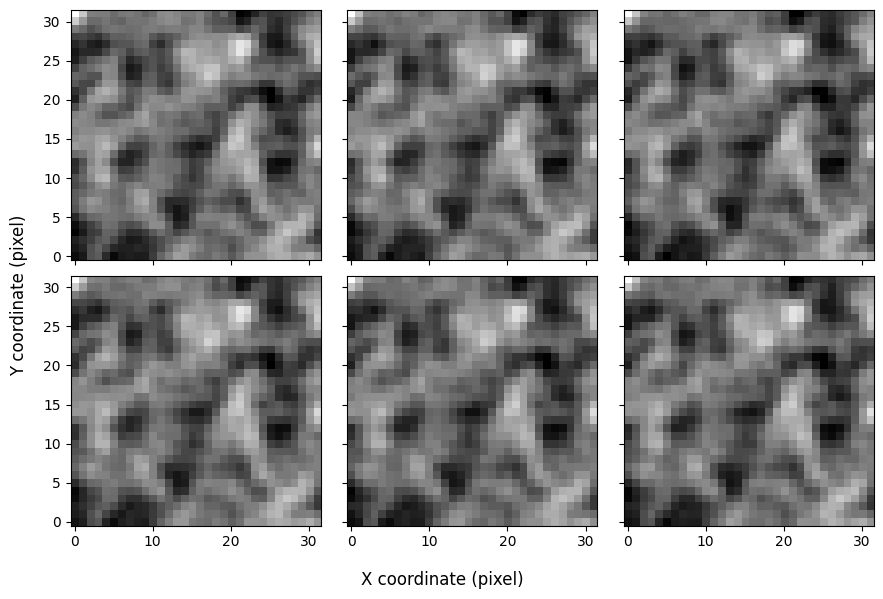

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(9, 6), sharex=True, sharey=True)

for n, ax in enumerate(axes.flatten()):
  ax.imshow(cube[n], cmap='gray')

fig.supxlabel('X coordinate (pixel)', fontsize=12)
fig.supylabel('Y coordinate (pixel)', fontsize=12)

fig.tight_layout()
plt.show()

## Fit a rank-2 background with BIRSVD

Reshape the data cube to `(time, y * x)`, with one full detector frame per
row. Convert the fixed source mask to observation weights using
`weight = 1 - mask`, then reshape it in the same way. Excluded pixels
have zero weight in the data-fitting term; the mask is not updated.

Call `birsvd(data, weight, n_rank)` with `n_rank = 2` to jointly estimate
two spatial basis images and their frame-wise coefficients. The routine
alternately solves for the factors using weighted least squares with
the library default regularization and iteration settings.

`result.A` reconstructs the background as `U @ diag(S) @ V.T`, including
the masked pixels. `result.residual(data)` returns `data - result.A`.


In [4]:
data = cube.reshape(nz, ny * nx)
weight = (1.0 - mask).reshape(nz, ny * nx)
n_rank = 2

param = BIRSVDParameter(
  n_iter=50,
  r_degree_L=0.0001,
  r_degree_R=0.0001,
)

result = birsvd(data, weight, n_rank, param=param)
res = result.residual(data)

## Inspect the reconstructed background and source

Restore the matrix outputs to `(time, y, x)` and compare one input frame
with its background, residual, and fixed mask. `sparse = mask * residual`
retains residual values only in the masked source region.

The panel labelled `uncertainty` currently repeats the input frame as a
placeholder. This notebook does not compute an uncertainty estimate.


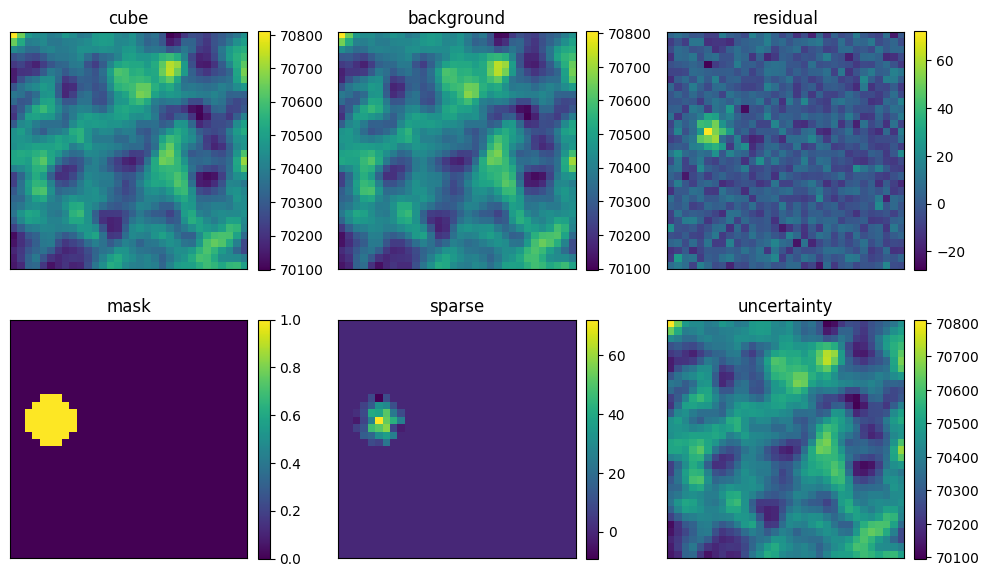

In [5]:
frame_index = 8
background = result.A.reshape(nz, ny, nx)
residual = res.reshape(nz, ny, nx)
maskcube = mask.reshape(nz, ny, nx)
sparse = maskcube * residual

fig, axes = plt.subplots(2, 3, figsize=(10, 6))
items = [
  ('cube', cube[frame_index]),
  ('background', background[frame_index]),
  ('residual', residual[frame_index]),
  ('mask', maskcube[frame_index]),
  ('sparse', sparse[frame_index]),
  ('uncertainty', cube[frame_index]),
]

for axis, (title, image) in zip(axes.ravel(), items):
  handle = axis.imshow(image, origin='lower', cmap='viridis')
  axis.set_title(title)
  axis.set_xticks([])
  axis.set_yticks([])
  fig.colorbar(handle, ax=axis, fraction=0.046, pad=0.04)

fig.tight_layout()
plt.show()

In [6]:
hdul = fits.HDUList([
  fits.PrimaryHDU(data=residual),
  fits.ImageHDU(data=background, name='MODEL'),
  fits.ImageHDU(data=maskcube.astype('int16'), name='MASK'),
  fits.ImageHDU(data=sparse, name='SPARSE'),
])
hdul.writeto('../data/tutorial_BIRSVD.fits', overwrite=True)

## Inspect the spatial basis images

Reshape the two columns of `result.V` to detector images. These are the
spatial basis vectors; their frame-wise amplitudes are given by the
corresponding columns of `U` multiplied by the singular values `S`.


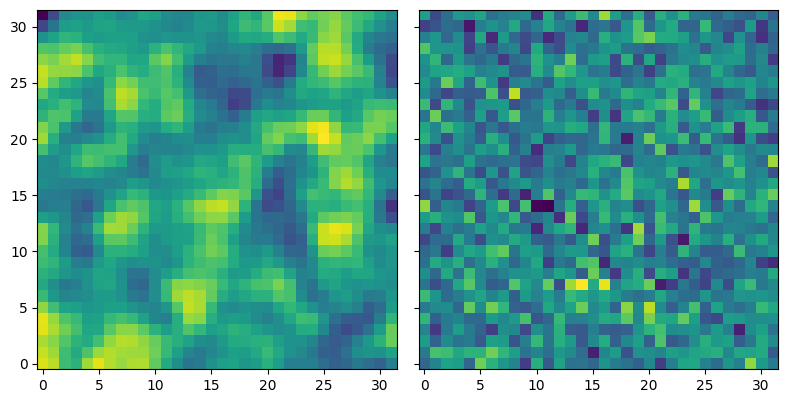

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)

axes[0].imshow(result.V[:, 0].reshape(ny, nx))
axes[1].imshow(result.V[:, 1].reshape(ny, nx))

fig.tight_layout()
plt.show()